In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

## connect to database and upload data

In [9]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [10]:
table_checker = pd.read_sql(
    '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
''', conn, parse_dates='timestamp'
)
table_checker

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [11]:
table_checker['day_name'] = table_checker.timestamp.dt.day_name()
table_checker['hour'] = table_checker.timestamp.dt.hour
table_checker

,uid,timestamp,day_name,hour
0,user_4,2020-04-17 05:19:02.744528,Friday,5
1,user_4,2020-04-17 05:22:35.249331,Friday,5
2,user_4,2020-04-17 05:22:45.549397,Friday,5
3,user_4,2020-04-17 05:34:14.691200,Friday,5
4,user_4,2020-04-17 05:34:24.422370,Friday,5
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,Thursday,20
3203,user_1,2020-05-21 20:22:41.785725,Thursday,20
3204,user_1,2020-05-21 20:22:41.877806,Thursday,20
3205,user_1,2020-05-21 20:37:00.129678,Thursday,20


## table for week days

In [12]:
week_days_talbe = pd.pivot_table(table_checker,
                                 values='timestamp',
                                 index='day_name',
                                 columns='uid',
                                 aggfunc='count',
                                 fill_value=0,
                                 )
week_days_talbe = week_days_talbe[week_days_talbe.sum().sort_values(ascending=False).index]
correct_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
week_days_talbe = week_days_talbe.reindex(correct_order)
week_days_talbe

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
day_name,,,,,,,,,,,,,,,,,,,,,
Monday,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,2,0,0,3
Tuesday,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,5,3,0,0,0
Wednesday,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,3,0,0,0,0
Thursday,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,2,0,6,0
Friday,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0
Saturday,0,79,31,66,21,16,3,90,4,3,...,32,0,0,4,2,0,0,0,0,0
Sunday,45,26,13,44,51,69,28,7,2,8,...,0,31,27,20,9,0,1,8,0,0


## table for hours

In [13]:
hours_talbe = pd.pivot_table(table_checker,
                             values='timestamp',
                             columns='uid',
                             index='hour',
                             aggfunc='count',
                             fill_value=0)
hours_talbe = hours_talbe[hours_talbe.sum().sort_values(ascending=False).index]
hours_talbe

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0,4,0,0,0,4,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
1,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,13,0,2,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,3,6,0,0,10,2,0,3,0,...,1,0,0,0,0,0,0,0,0,0
8,0,6,0,0,0,5,2,0,9,6,...,2,0,0,0,0,1,0,0,1,0
9,0,4,13,0,0,3,0,1,0,3,...,0,0,0,2,0,0,3,0,0,0
10,26,2,42,18,20,16,0,0,0,2,...,7,0,0,0,0,0,0,0,0,0


## make a heatmaps

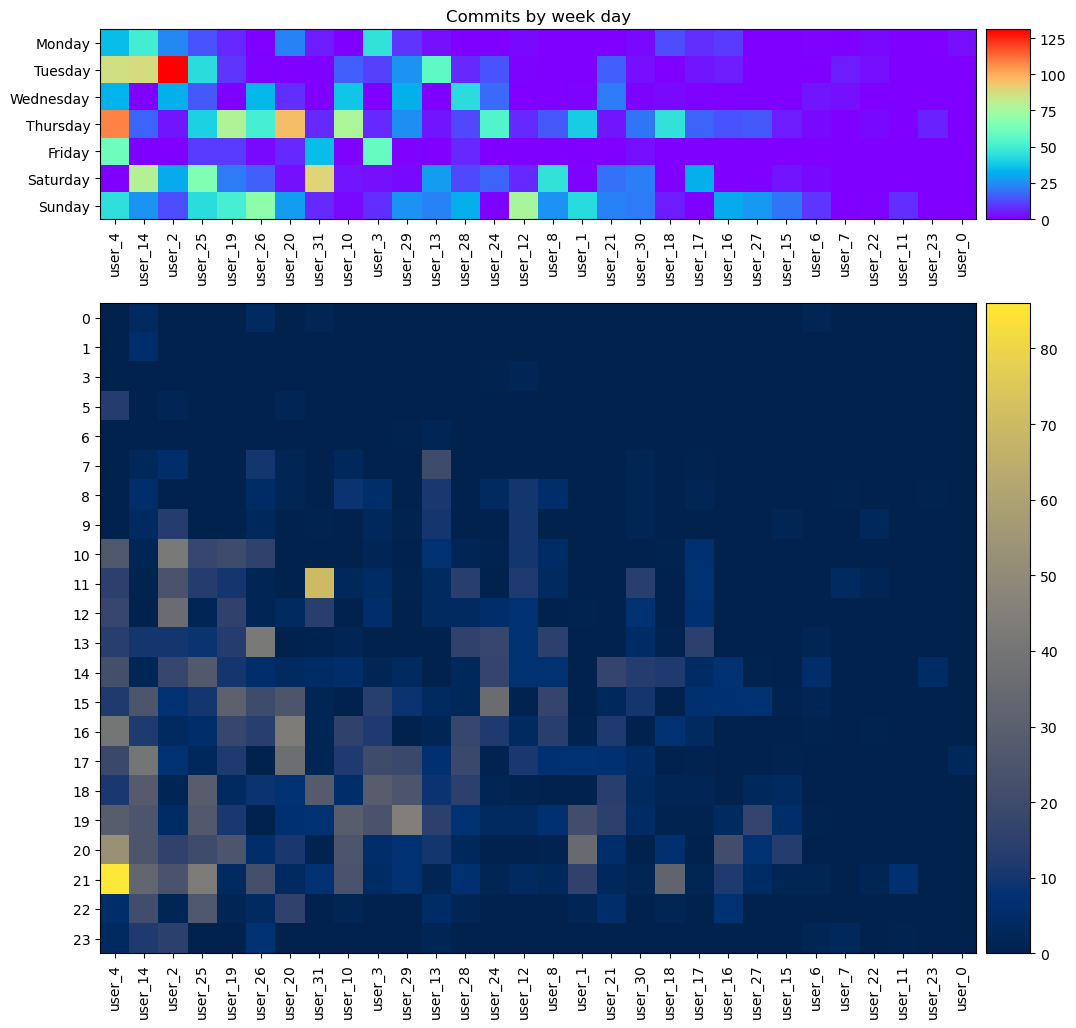

In [14]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12,12), gridspec_kw={'height_ratios' : [7,24]})

divider0 = make_axes_locatable(ax[0])
divider1 = make_axes_locatable(ax[1])

im0 = ax[0].imshow(week_days_talbe, cmap = 'rainbow',aspect='auto')
ax[0].set_xticks(range(week_days_talbe.shape[1]))
ax[0].set_xticklabels(week_days_talbe.columns, rotation=90)
ax[0].set_yticks(range(week_days_talbe.shape[0]))
ax[0].set_yticklabels(week_days_talbe.index)
ax[0].set_title('Commits by week day')

cax0 = divider0.append_axes('right', size='5%', pad=0.1)
plt.colorbar(im0, cax=cax0)


im1 = ax[1].imshow(hours_talbe, cmap='cividis', aspect='auto')
ax[1].set_xticks(range(hours_talbe.shape[1]))
ax[1].set_xticklabels(hours_talbe.columns, rotation=90)
ax[1].set_yticks(range(hours_talbe.shape[0]))
ax[1].set_yticklabels(hours_talbe.index)

cax1 = divider1.append_axes('right', size='5%', pad=0.1)
plt.colorbar(im1, cax=cax1)





In [15]:
conn.close()

## Which user has the most commits on Tue? - user_2

## Which user has the most commits on Thu ? - user_4

## On which weekday do the users not like making a lot of commits? - Friday

## Which user at which hour made the largest number of commits? - user_4 21